1. Import

In [ ]:
import os
import zipfile
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

layers = tf.keras.layers
models = tf.keras.models
applications = tf.keras.applications
optimizers = tf.keras.optimizers
callbacks = tf.keras.callbacks
preprocessing = tf.keras.preprocessing.image

from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.19.0


In [ ]:
print("Available GPUs:", tf.config.list_physical_devices('GPU'))

Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


2. Load dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
BASE_DATASET_PATH = "/content/drive/MyDrive/dataset"

print("Dataset folders:")
print(os.listdir(BASE_DATASET_PATH))


Dataset folders:
['Potato___Late_blight', 'Tomato___Late_blight', 'Tomato___healthy', 'Tomato___Early_blight', 'Pepper,_bell___healthy', 'Potato___healthy', 'Potato___Early_blight', 'Corn___Northern_Leaf_Blight', 'Pepper,_bell___Bacterial_spot', 'Corn___healthy', 'Corn___Common_rust']


3. CREATE MAIN TRAINING SET (POTATO + TOMATO)

In [ ]:
train_main = "/content/train_main"
os.makedirs(train_main, exist_ok=True)

main_classes = [
    "Potato___Early_blight", "Potato___Late_blight", "Potato___healthy",
    "Tomato___Early_blight", "Tomato___Late_blight", "Tomato___healthy"
]

for cls in main_classes:
    shutil.copytree(
        os.path.join(BASE_DATASET_PATH, cls),
        os.path.join(train_main, cls),
        dirs_exist_ok=True
    )

print("Training classes:", os.listdir(train_main))


Training classes: ['Potato___Early_blight', 'Potato___healthy', 'Tomato___Late_blight', 'Tomato___healthy', 'Potato___Late_blight', 'Tomato___Early_blight']


4. CREATE GENERALIZATION SET (CORN + PEPPER)

In [ ]:
test_generalization = "/content/test_generalization"
os.makedirs(test_generalization, exist_ok=True)

gen_classes = [
    "Corn___Common_rust", "Corn___Northern_Leaf_Blight", "Corn___healthy",
    "Pepper,_bell___Bacterial_spot", "Pepper,_bell___healthy"
]

for cls in gen_classes:
    shutil.copytree(
        os.path.join(BASE_DATASET_PATH, cls),
        os.path.join(test_generalization, cls),
        dirs_exist_ok=True
    )

print("Generalization classes:", os.listdir(test_generalization))


Generalization classes: ['Corn___healthy', 'Pepper,_bell___Bacterial_spot', 'Corn___Northern_Leaf_Blight', 'Pepper,_bell___healthy', 'Corn___Common_rust']


5. DATA GENERATORS (MILD AUGMENTATION)

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = preprocessing.ImageDataGenerator(
    preprocessing_function=applications.mobilenet_v2.preprocess_input,
    rotation_range=10,
    zoom_range=0.1,
    brightness_range=[0.9, 1.1],
    horizontal_flip=True,
    validation_split=0.15
)

val_datagen = preprocessing.ImageDataGenerator(
    preprocessing_function=applications.mobilenet_v2.preprocess_input,
    validation_split=0.15
)


6. LOAD TRAIN & VALIDATION DATA

In [ ]:
train_gen = train_datagen.flow_from_directory(
    train_main,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training"
)

val_gen = val_datagen.flow_from_directory(
    train_main,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

class_names = list(train_gen.class_indices.keys())
num_classes = train_gen.num_classes

print("Classes:", class_names)


Found 5656 images belonging to 6 classes.
Found 996 images belonging to 6 classes.
Classes: ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___healthy']


7. BUILD LIGHTWEIGHT CNN (MobileNetV2)

In [ ]:
base_model = applications.MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs=base_model.input, outputs=output)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


8. COMPILE MODEL

In [ ]:
model.compile(
    optimizer=optimizers.Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

9. TRAIN MODEL

In [ ]:
early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=[early_stop]
)


Epoch 1/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 79s 444ms/step - accuracy: 0.9155 - loss: 0.2525 - val_accuracy: 0.9247 - val_loss: 0.2023
Epoch 2/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 78s 440ms/step - accuracy: 0.9252 - loss: 0.2215 - val_accuracy: 0.9438 - val_loss: 0.1818
Epoch 3/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 77s 436ms/step - accuracy: 0.9294 - loss: 0.2183 - val_accuracy: 0.9367 - val_loss: 0.1788
Epoch 4/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 78s 443ms/step - accuracy: 0.9361 - loss: 0.1881 - val_accuracy: 0.9498 - val_loss: 0.1592
Epoch 5/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 76s 431ms/step - accuracy: 0.9430 - loss: 0.1701 - val_accuracy: 0.9458 - val_loss: 0.1636
Epoch 6/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 79s 444ms/step - accuracy: 0.9431 - loss: 0.1644 - val_accuracy: 0.9498 - val_loss: 0.1532
Epoch 7/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 76s 428ms/step - accuracy: 0.9363 - loss: 0.1714 - val_accuracy: 0.9538 - val_loss: 0.1464
Epoch 8/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 75s 423ms/step - accuracy: 0.9443 - loss: 0

In [ ]:
print("Best val_loss achieved:", min(history_1.history["val_loss"]))


Best val_loss achieved: 0.11827202886343002


10. TRAINING CURVES

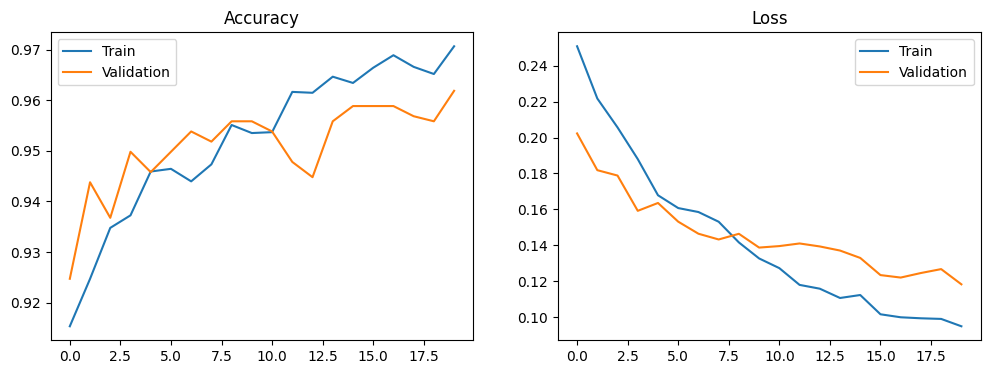

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_1.history["accuracy"], label="Train")
plt.plot(history_1.history["val_accuracy"], label="Validation")
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_1.history["loss"], label="Train")
plt.plot(history_1.history["val_loss"], label="Validation")
plt.title("Loss")
plt.legend()

plt.show()


11. EVALUATION (MAIN CROPS)

In [ ]:
val_gen.reset()
preds = model.predict(val_gen)
y_pred = np.argmax(preds, axis=1)
y_true = val_gen.classes

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))


32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 178ms/step
                       precision    recall  f1-score   support

Potato___Early_blight       0.99      0.97      0.98       150
 Potato___Late_blight       0.97      0.91      0.94       150
     Potato___healthy       0.91      0.95      0.93        22
Tomato___Early_blight       0.93      0.93      0.93       150
 Tomato___Late_blight       0.96      0.97      0.96       286
     Tomato___healthy       0.98      1.00      0.99       238

             accuracy                           0.96       996
            macro avg       0.95      0.96      0.96       996
         weighted avg       0.96      0.96      0.96       996



12. CONFUSION MATRIX

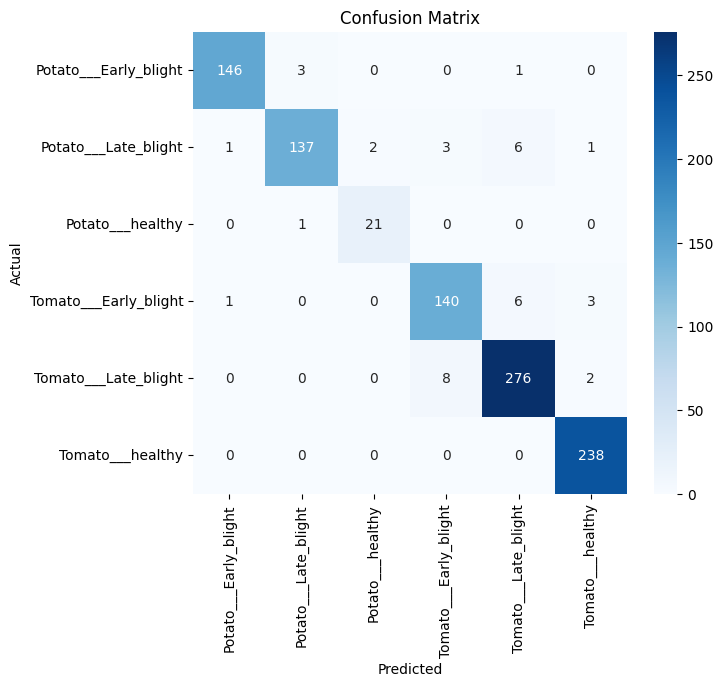

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
model.save("lightweight_model.h5")
size_mb = os.path.getsize("lightweight_model.h5") / (1024 * 1024)
print(f"Model size: {size_mb:.2f} MB")


Model size: 11.01 MB


In [ ]:
gen_datagen = preprocessing.ImageDataGenerator(rescale=1./255)

gen_test_gen = gen_datagen.flow_from_directory(
    test_generalization,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",   # labels exist for Corn/Pepper
    shuffle=False
)

Found 5814 images belonging to 5 classes.


In [ ]:
# Map class names to indices
class_indices = gen_test_gen.class_indices

# Identify healthy class indices
healthy_class_indices = [
    class_indices["Corn___healthy"],
    class_indices["Pepper,_bell___healthy"]
]

# True labels: 1 = healthy, 0 = diseased
y_true_binary = np.array([
    1 if cls in healthy_class_indices else 0
    for cls in gen_test_gen.classes
])


In [ ]:
preds = model.predict(gen_test_gen)
pred_classes = np.argmax(preds, axis=1)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


182/182 ━━━━━━━━━━━━━━━━━━━━ 25s 107ms/step


In [ ]:
# Training class names (Potato + Tomato)
train_class_names = list(train_gen.class_indices.keys())

# Map predicted classes to labels
pred_labels = [train_class_names[i] for i in pred_classes]

# Binary prediction: 1 = healthy, 0 = diseased
y_pred_binary = np.array([
    1 if "healthy" in lbl.lower() else 0
    for lbl in pred_labels
])


In [ ]:
print("Cross-Crop Generalization (Corn & Pepper)")
print(classification_report(
    y_true_binary,
    y_pred_binary,
    target_names=["Diseased", "Healthy"]
))

print("Confusion Matrix:")
print(confusion_matrix(y_true_binary, y_pred_binary))


Cross-Crop Generalization (Corn & Pepper)
              precision    recall  f1-score   support

    Diseased       0.71      0.81      0.75      3174
     Healthy       0.72      0.60      0.65      2640

    accuracy                           0.71      5814
   macro avg       0.71      0.70      0.70      5814
weighted avg       0.71      0.71      0.71      5814

Confusion Matrix:
[[2564  610]
 [1061 1579]]


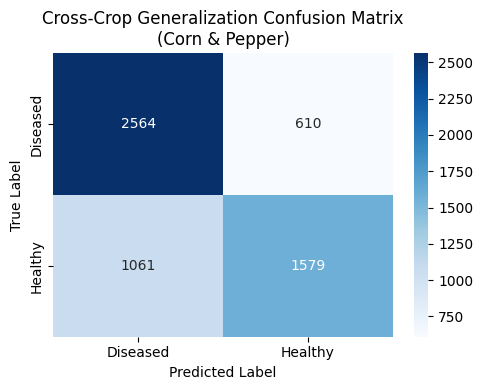

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_true_binary, y_pred_binary)

# Plot
plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Diseased", "Healthy"],
    yticklabels=["Diseased", "Healthy"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Cross-Crop Generalization Confusion Matrix\n(Corn & Pepper)")
plt.tight_layout()
plt.show()


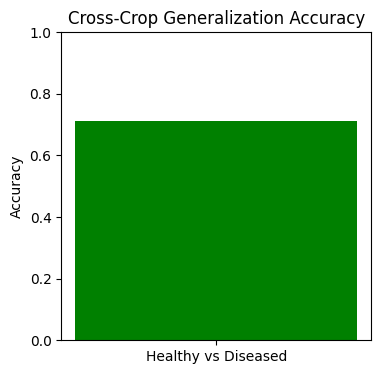

In [ ]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_true_binary, y_pred_binary)

plt.figure(figsize=(4,4))
plt.bar(["Healthy vs Diseased"], [acc], color="green")
plt.ylim(0,1)
plt.ylabel("Accuracy")
plt.title("Cross-Crop Generalization Accuracy")
plt.show()


13. CNN Comparison

In [ ]:
from tensorflow.keras import layers, models

cnn_model = models.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(num_classes,activation='softmax')
])

cnn_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
cnn_history = cnn_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20
)

Epoch 1/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 92s 477ms/step - accuracy: 0.5685 - loss: 1.2115 - val_accuracy: 0.8193 - val_loss: 0.5155
Epoch 2/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 78s 438ms/step - accuracy: 0.8583 - loss: 0.3838 - val_accuracy: 0.8012 - val_loss: 0.7238
Epoch 3/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 78s 442ms/step - accuracy: 0.9060 - loss: 0.2763 - val_accuracy: 0.7631 - val_loss: 0.8986
Epoch 4/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 78s 441ms/step - accuracy: 0.9137 - loss: 0.2463 - val_accuracy: 0.8544 - val_loss: 0.4833
Epoch 5/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 80s 451ms/step - accuracy: 0.9226 - loss: 0.2052 - val_accuracy: 0.8233 - val_loss: 0.6908
Epoch 6/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 79s 446ms/step - accuracy: 0.9432 - loss: 0.1541 - val_accuracy: 0.8865 - val_loss: 0.4471
Epoch 7/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 78s 440ms/step - accuracy: 0.9529 - loss: 0.1354 - val_accuracy: 0.8675 - val_loss: 0.6039
Epoch 8/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 80s 452ms/step - accuracy: 0.9597 - loss: 0

In [ ]:
cnn_loss, cnn_accuracy = cnn_model.evaluate(val_gen)

print("CNN Test Accuracy:", cnn_accuracy)
print("CNN Test Loss:", cnn_loss)

32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.8948 - loss: 0.5909
CNN Test Accuracy: 0.9206827282905579
CNN Test Loss: 0.36978262662887573


In [ ]:
cnn_model.save("cnn_model.h5")
cnn_size_mb = os.path.getsize("cnn_model.h5") / (1024 * 1024)
print(f"CNN model size: {cnn_size_mb:.2f} MB")

CNN model size: 127.87 MB


14. Crop generalistion in cnn

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

gen_datagen = ImageDataGenerator(rescale=1./255)

gen_test_gen = gen_datagen.flow_from_directory(
    test_generalization,   # your Corn + Pepper folder
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 5814 images belonging to 5 classes.


In [ ]:
cnn_preds = cnn_model.predict(gen_test_gen)

182/182 ━━━━━━━━━━━━━━━━━━━━ 14s 75ms/step


In [ ]:
cnn_pred_classes = np.argmax(cnn_preds, axis=1)
print("Shape of cnn_pred_classes:", cnn_pred_classes.shape)

Shape of cnn_pred_classes: (5814,)


In [ ]:
cnn_pred_labels = [train_class_names[i] for i in cnn_pred_classes]
cnn_y_pred_binary = np.array([
    1 if "healthy" in lbl.lower() else 0
    for lbl in cnn_pred_labels
])

print("Shape of cnn_y_pred_binary:", cnn_y_pred_binary.shape)

Shape of cnn_y_pred_binary: (5814,)


In [ ]:
print("Custom CNN Cross-Crop Generalization (Corn & Pepper)")
print(classification_report(
    y_true_binary,
    cnn_y_pred_binary,
    target_names=["Diseased", "Healthy"]
))

print("Confusion Matrix:")
print(confusion_matrix(y_true_binary, cnn_y_pred_binary))

Custom CNN Cross-Crop Generalization (Corn & Pepper)
              precision    recall  f1-score   support

    Diseased       0.59      0.95      0.73      3174
     Healthy       0.76      0.20      0.32      2640

    accuracy                           0.61      5814
   macro avg       0.68      0.58      0.52      5814
weighted avg       0.67      0.61      0.54      5814

Confusion Matrix:
[[3007  167]
 [2100  540]]


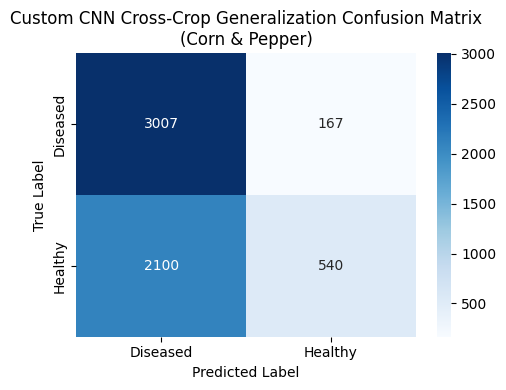

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix for custom CNN
cnn_cm = confusion_matrix(y_true_binary, cnn_y_pred_binary)

# Plot
plt.figure(figsize=(5,4))
sns.heatmap(
    cnn_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Diseased", "Healthy"],
    yticklabels=["Diseased", "Healthy"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Custom CNN Cross-Crop Generalization Confusion Matrix\n(Corn & Pepper)")
plt.tight_layout()
plt.show()

**Reasoning**:
Now that the custom CNN has been evaluated on the generalization dataset, I need to update the comparison DataFrame to include its cross-crop generalization accuracy. This will provide a complete overview of both models' performances.



In [ ]:
import pandas as pd

# Extract metrics for the Lightweight CNN (MobileNetV2)
lightweight_val_accuracy = history_1.history["val_accuracy"][-1] if history_1 and "val_accuracy" in history_1.history else "N/A"
lightweight_val_loss = min(history_1.history["val_loss"]) if history_1 and "val_loss" in history_1.history else "N/A"
lightweight_gen_accuracy = acc if 'acc' in globals() else "N/A"
lightweight_model_size = f"{size_mb:.2f} MB" if 'size_mb' in globals() else "N/A"

# Calculate custom CNN generalization accuracy
custom_cnn_gen_accuracy_val = accuracy_score(y_true_binary, cnn_y_pred_binary) if 'cnn_y_pred_binary' in globals() and 'y_true_binary' in globals() else "Not evaluated"

# Extract metrics for the Custom CNN
custom_cnn_val_accuracy = cnn_accuracy if 'cnn_accuracy' in globals() else "N/A"
custom_cnn_val_loss = cnn_loss if 'cnn_loss' in globals() else "N/A"
custom_cnn_model_size = f"{cnn_size_mb:.2f} MB" if 'cnn_size_mb' in globals() else "N/A"

# Create a DataFrame for comparison
comparison_data = {
    'Feature': [
        'Main Crops Validation Accuracy',
        'Main Crops Validation Loss',
        'Cross-Crop Generalization Accuracy (Corn & Pepper)',
        'Model Size'
    ],
    'Lightweight CNN (MobileNetV2)': [
        lightweight_val_accuracy,
        lightweight_val_loss,
        lightweight_gen_accuracy,
        lightweight_model_size
    ],
    'Custom CNN': [
        custom_cnn_val_accuracy,
        custom_cnn_val_loss,
        custom_cnn_gen_accuracy_val,
        custom_cnn_model_size
    ]
}

comparison_df = pd.DataFrame(comparison_data)

display(comparison_df)

,Feature,Lightweight CNN (MobileNetV2),Custom CNN
0,Main Crops Validation Accuracy,0.961847,0.920683
1,Main Crops Validation Loss,0.118272,0.369783
2,Cross-Crop Generalization Accuracy (Corn & Pep...,0.71259,0.610079
3,Model Size,11.01 MB,127.87 MB


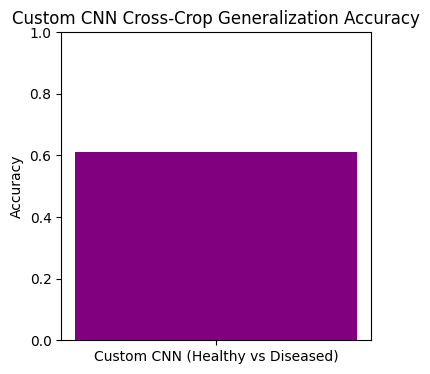

Custom CNN Cross-Crop Generalization Accuracy: 0.6101


In [ ]:
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Calculate custom CNN generalization accuracy
custom_cnn_gen_accuracy_val = accuracy_score(y_true_binary, cnn_y_pred_binary)

# Plot the accuracy
plt.figure(figsize=(4,4))
plt.bar(["Custom CNN (Healthy vs Diseased)"], [custom_cnn_gen_accuracy_val], color="purple")
plt.ylim(0,1)
plt.ylabel("Accuracy")
plt.title("Custom CNN Cross-Crop Generalization Accuracy")
plt.show()

print(f"Custom CNN Cross-Crop Generalization Accuracy: {custom_cnn_gen_accuracy_val:.4f}")

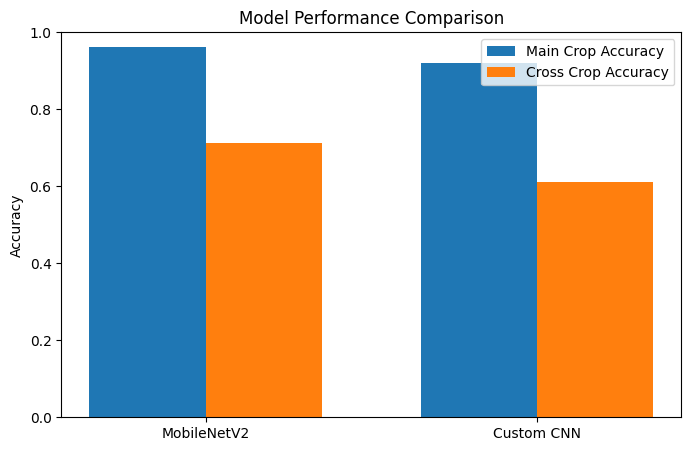

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = ["MobileNetV2", "Custom CNN"]

main_accuracy = [0.961847, 0.920683]
cross_crop = [0.71259, 0.610079]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, main_accuracy, width, label="Main Crop Accuracy")
plt.bar(x + width/2, cross_crop, width, label="Cross Crop Accuracy")

plt.xticks(x, models)
plt.ylabel("Accuracy")
plt.title("Model Performance Comparison")
plt.legend()

plt.ylim(0,1)

plt.show()

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,752,212 (10.50 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 329,486 (1.26 MB)

**Reasoning**:
To get the total, trainable, and non-trainable parameters for the Custom CNN model, I will print its summary using `cnn_model.summary()`.



In [ ]:
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,509,204 (127.83 MB)

 Trainable params: 11,169,734 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 22,339,470 (85.22 MB)

In [ ]:
import pandas as pd

# Retrieve training epochs for each model
# The number of epochs is the length of the history object's metric lists
lightweight_epochs = len(history_1.history['accuracy'])
custom_cnn_epochs = len(cnn_history.history['accuracy'])

# Ensure all previous metrics are available
# Extract metrics for the Lightweight CNN (MobileNetV2)
lightweight_val_accuracy = history_1.history["val_accuracy"][-1] if history_1 and "val_accuracy" in history_1.history else "N/A"
lightweight_val_loss = min(history_1.history["val_loss"]) if history_1 and "val_loss" in history_1.history else "N/A"
lightweight_gen_accuracy = acc if 'acc' in globals() else "N/A"
lightweight_model_size = f"{size_mb:.2f} MB" if 'size_mb' in globals() else "N/A"

# Manually extracted parameters from model.summary() output
lightweight_total_params = 2752212
lightweight_trainable_params = 164742
lightweight_nontrainable_params = 2257984

# Calculate custom CNN generalization accuracy
custom_cnn_gen_accuracy_val = accuracy_score(y_true_binary, cnn_y_pred_binary) if 'cnn_y_pred_binary' in globals() and 'y_true_binary' in globals() else "Not evaluated"

# Extract metrics for the Custom CNN
custom_cnn_val_accuracy = cnn_accuracy if 'cnn_accuracy' in globals() else "N/A"
custom_cnn_val_loss = cnn_loss if 'cnn_loss' in globals() else "N/A"
custom_cnn_model_size = f"{cnn_size_mb:.2f} MB" if 'cnn_size_mb' in globals() else "N/A"

# Manually extracted parameters from cnn_model.summary() output
custom_cnn_total_params = 33509204
custom_cnn_trainable_params = 11169734
custom_cnn_nontrainable_params = 0

# Create a DataFrame for comparison, including the new 'Training Epochs' row
comparison_data = {
    'Feature': [
        'Main Crops Validation Accuracy',
        'Main Crops Validation Loss',
        'Cross-Crop Generalization Accuracy (Corn & Pepper)',
        'Model Size',
        'Total Parameters',
        'Trainable Parameters',
        'Non-Trainable Parameters',
        'Training Epochs'
    ],
    'Lightweight CNN (MobileNetV2)': [
        lightweight_val_accuracy,
        lightweight_val_loss,
        lightweight_gen_accuracy,
        lightweight_model_size,
        lightweight_total_params,
        lightweight_trainable_params,
        lightweight_nontrainable_params,
        lightweight_epochs
    ],
    'Custom CNN': [
        custom_cnn_val_accuracy,
        custom_cnn_val_loss,
        custom_cnn_gen_accuracy_val,
        custom_cnn_model_size,
        custom_cnn_total_params,
        custom_cnn_trainable_params,
        custom_cnn_nontrainable_params,
        custom_cnn_epochs
    ]
}

comparison_df = pd.DataFrame(comparison_data)

display(comparison_df)

,Feature,Lightweight CNN (MobileNetV2),Custom CNN
0,Main Crops Validation Accuracy,0.961847,0.920683
1,Main Crops Validation Loss,0.118272,0.369783
2,Cross-Crop Generalization Accuracy (Corn & Pep...,0.71259,0.610079
3,Model Size,11.01 MB,127.87 MB
4,Total Parameters,2752212,33509204
5,Trainable Parameters,164742,11169734
6,Non-Trainable Parameters,2257984,0
7,Training Epochs,20,20


## Visualize Model Performance and Size Comparison

### Subtask:
Generate a comparative plot (e.g., bar chart) for key metrics like main crop accuracy, cross-crop generalization accuracy, model size, and parameters for both the Lightweight CNN and the Custom CNN.


**Reasoning**:
I will extract the necessary accuracy data from the `comparison_df` for both models and create a grouped bar chart to visualize their main crop validation accuracy and cross-crop generalization accuracy, ensuring clear labels and a title.



**Reasoning**:
I will extract the model size data from the `comparison_df` for both models and create a bar chart to visualize their sizes, ensuring clear labels and a title. This addresses the second plotting instruction.



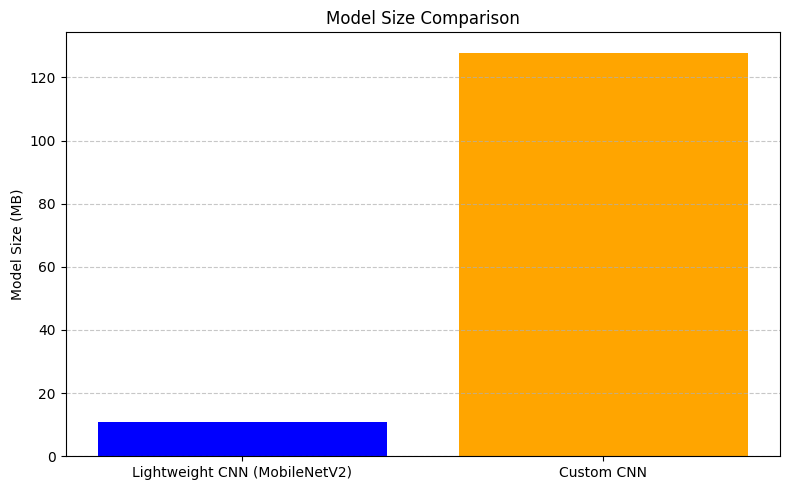

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Extract model size data
model_size_str = comparison_df[comparison_df['Feature'] == 'Model Size'].iloc[0, 1:].values
model_sizes = [float(s.replace(' MB', '')) for s in model_size_str] # Convert 'X.XX MB' to float

plt.figure(figsize=(8, 5))
plt.bar(models, model_sizes, color=['blue', 'orange'])
plt.ylabel('Model Size (MB)')
plt.title('Model Size Comparison')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Reasoning**:
I will extract the 'Total Parameters' data from the `comparison_df` for both models and create a bar chart to visualize this comparison, including clear labels and a title. This addresses the third plotting instruction.



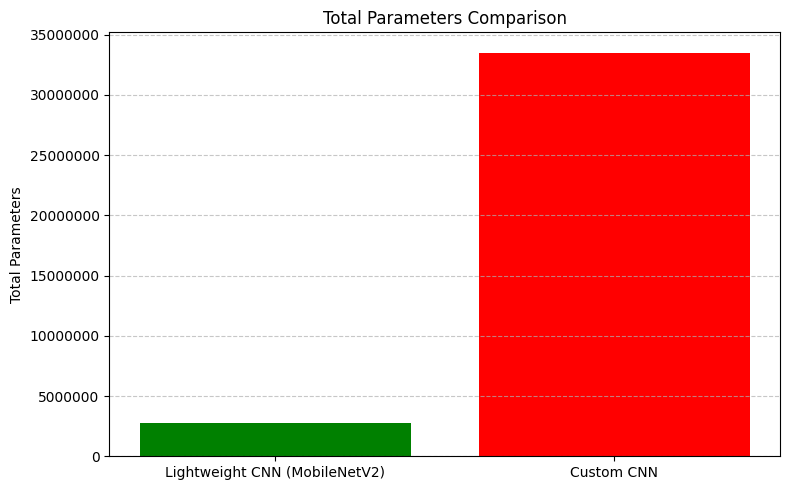

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Extract total parameters data
total_params = comparison_df[comparison_df['Feature'] == 'Total Parameters'].iloc[0, 1:].values.astype(float)

plt.figure(figsize=(8, 5))
plt.bar(models, total_params, color=['green', 'red'])
plt.ylabel('Total Parameters')
plt.title('Total Parameters Comparison')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ticklabel_format(style='plain', axis='y') # Prevent scientific notation for y-axis
plt.tight_layout()
plt.show()

**Reasoning**:
I will extract the 'Trainable Parameters' data from the `comparison_df` for both models and create a bar chart to visualize this comparison, including clear labels and a title. This addresses the fourth plotting instruction.



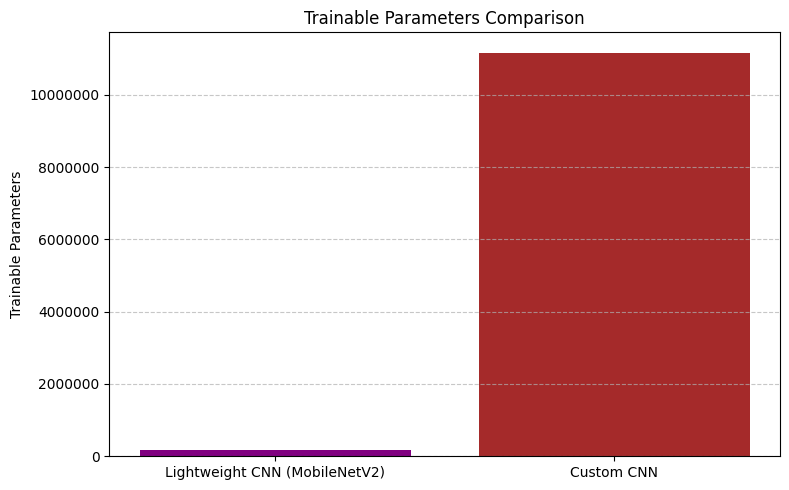

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Extract trainable parameters data
trainable_params = comparison_df[comparison_df['Feature'] == 'Trainable Parameters'].iloc[0, 1:].values.astype(float)

plt.figure(figsize=(8, 5))
plt.bar(models, trainable_params, color=['purple', 'brown'])
plt.ylabel('Trainable Parameters')
plt.title('Trainable Parameters Comparison')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ticklabel_format(style='plain', axis='y') # Prevent scientific notation for y-axis
plt.tight_layout()
plt.show()